Contexte 
Une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT. Chaque capteur 
collecte régulièrement des informations sur la température, l'humidité, la qualité de l'air, la 
consommation énergétique, le nombre de personnes présentes, le type de bâtiment, le mode de 
fonctionnement et l'état du système de climatisation. 
Les données collectées sont destinées à alimenter ultérieurement un modèle de Machine Learning 
capable de prédire la consommation énergétique ou de détecter les situations anormales. 
Cependant, les données brutes présentent volontairement différents problèmes : valeurs 
manquantes, doublons, valeurs aberrantes, types incorrects, valeurs incohérentes, variables 
catégorielles, catégories rares, déséquilibre des classes et échelles différentes entre variables. 
L'objectif de l'atelier est donc de transformer le fichier brut en un jeu de données propre et prêt 
pour le Machine Learning.

Partie 1 – Explorer les données 

In [59]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1) Charger les données CSV 


In [60]:
df=pd.read_csv('../data/smart_building_raw.csv')

2) Afficher les premières lignes du dataset 

In [61]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


3) Afficher les dernières lignes du dataset ; 

In [62]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


4) Combien d'observations contient le dataset ?

In [63]:
df.shape[0]

507

5) Combien de variables possède le dataset ? 

In [64]:
df.shape[1]

14

6) Identifier les variables numériques 

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_mesure           507 non-null    int64  
 1   date                507 non-null    str    
 2   batiment            507 non-null    str    
 3   type_batiment       503 non-null    str    
 4   zone                507 non-null    str    
 5   temperature         495 non-null    float64
 6   humidite            496 non-null    float64
 7   co2                 500 non-null    float64
 8   occupation          501 non-null    float64
 9   consommation_kwh    502 non-null    float64
 10  mode_climatisation  502 non-null    str    
 11  etat_systeme        507 non-null    str    
 12  jour_semaine        502 non-null    str    
 13  alerte              507 non-null    str    
dtypes: float64(5), int64(1), str(8)
memory usage: 55.6 KB


les variables numériquues sont:  
[id_mesure]   
[temperature]
[humidite]   
[co2] 
[occupation]  
[consommation_kwh]

7) Identifier les variables catégorielles 


Les variables catégorielles sont :

[mode_climatisation]    
[etat_systeme]  
[jour_semaine]   
[alerte]

8) Identifier les dates 

Les variables dates sont:

[date] 

9) Identifier les identifiants

Les identifiants sont:

[id_mesure]

10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles. 

In [66]:
num = df.select_dtypes(include='number')

stats = pd.DataFrame({
    'moyenne':    num.mean(),
    'médiane':    num.median(),
    'minimum':    num.min(),
    'maximum':    num.max(),
    'écart-type': num.std(),
    'Q1 (25%)':   num.quantile(0.25),
    'Q3 (75%)':   num.quantile(0.75),
})

print(stats)

                      moyenne  médiane  minimum  maximum  écart-type  \
id_mesure         1251.114398  1252.00   1001.0   1500.0  144.782769   
temperature         24.154141    24.00    -30.0     96.0    7.418465   
humidite            57.864113    57.55    -12.0    160.0   16.026336   
co2                844.150000   787.50     89.0   6000.0  582.181386   
occupation          44.850299    46.00    -20.0    116.0   24.949139   
consommation_kwh   169.069323   169.80   -100.0    336.2   53.164294   

                  Q1 (25%)  Q3 (75%)  
id_mesure         1125.500  1376.500  
temperature         21.600    26.000  
humidite            49.275    65.750  
co2                623.750   952.000  
occupation          27.000    61.000  
consommation_kwh   136.875   202.975  


11) Y a-t-il des variables potentiellement problématiques ? 

La variable [date] peut etre considere comme problematique tenant compte du type qui es : "str" 

12) Pour les données incohérentes : 

a) rechercher des valeurs telles que humidité < 0 

In [67]:
df[df['humidite'] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
281,1126,2025-02-01 06:00:00,B2,École,D,24.8,-5.0,759.0,57.0,225.2,Boost,Normal,Samedi,Non
335,1036,2025-01-09 18:00:00,B4,Bureau,D,21.2,-8.0,160.0,25.0,120.2,Normal,Alerte,Jeudi,Non
366,1216,2025-02-23 18:00:00,B3,Hôpital,B,23.2,-12.0,702.0,41.0,119.8,Normal,Normal,Dimanche,Non


b) rechercher des valeurs telles que humidité > 100  

In [68]:
df[df['humidite'] <100]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui


c) rechercher des valeurs telles que température extrêmement élevée ;

In [69]:
df[df['temperature'] >40]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
7,1141,2025-02-05 00:00:00,B2,École,D,72.5,78.3,257.0,100.0,239.7,Boost,Alerte,Mercredi,Non
116,1181,2025-02-15 00:00:00,B6,Université,A,96.0,86.5,874.0,115.0,241.5,Normal,Normal,Samedi,Non
161,1061,2025-01-16 00:00:00,B5,Centre commercial,D,88.0,50.5,393.0,62.0,196.6,Normal,Alerte,Jeudi,Non
499,1021,2025-01-06 00:00:00,B2,École,A,95.2,65.0,314.0,43.0,246.3,Normal,Normal,Lundi,Non


d) rechercher des valeurs telles que négative ; 

In [70]:
num = df.select_dtypes(include='number')

# neg_count = (num < 0).sum()
# print(neg_count)
# print(neg_count[neg_count > 0])

print(df[(num < 0).any(axis=1)])

     id_mesure                 date batiment      type_batiment zone  \
22        1031  2025-01-08 12:00:00       B2              École    D   
59        1246  2025-03-03 06:00:00       B5  Centre commercial    A   
154       1046  2025-01-12 06:00:00       B2              École    B   
185       1221  2025-02-25 00:00:00       B8           Entrepôt    D   
199       1146  2025-02-06 06:00:00       B7              Bureu    C   
281       1126  2025-02-01 06:00:00       B2              École    D   
335       1036  2025-01-09 18:00:00       B4             Bureau    D   
358       1101  2025-01-26 00:00:00       B6  centre commercial    D   
366       1216  2025-02-23 18:00:00       B3            Hôpital    B   
376       1231  2025-02-27 12:00:00       B7             Bureau    D   
430       1081  2025-01-21 00:00:00       B1             Bureau    B   
441       1346  2025-03-28 06:00:00       B5  Centre commercial    D   
487       1131  2025-02-02 12:00:00       B1           entrepot 

e) rechercher des valeurs telles que consommation négative 

In [71]:
df[df['consommation_kwh'] <0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
154,1046,2025-01-12 06:00:00,B2,École,B,21.0,59.4,894.0,33.0,-50.0,Normal,Normal,Dimanche,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
441,1346,2025-03-28 06:00:00,B5,Centre commercial,D,29.0,44.1,834.0,6.0,-100.0,Eco,Normal,Vendredi,Non


f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la 
transformer en valeur manquante 

In [72]:
df.loc[~df['humidite'].between(0, 100), 'humidite'] = np.nan
df.loc[(df['temperature'] < -10) | (df['temperature'] > 50), 'temperature'] = np.nan
for col in ['co2', 'occupation', 'consommation_kwh']:
    df.loc[df[col] < 0, col] = np.nan
    

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_mesure           507 non-null    int64  
 1   date                507 non-null    str    
 2   batiment            507 non-null    str    
 3   type_batiment       503 non-null    str    
 4   zone                507 non-null    str    
 5   temperature         489 non-null    float64
 6   humidite            486 non-null    float64
 7   co2                 500 non-null    float64
 8   occupation          496 non-null    float64
 9   consommation_kwh    498 non-null    float64
 10  mode_climatisation  502 non-null    str    
 11  etat_systeme        507 non-null    str    
 12  jour_semaine        502 non-null    str    
 13  alerte              507 non-null    str    
dtypes: float64(5), int64(1), str(8)
memory usage: 55.6 KB


g) rechercher des valeurs telles que catégories mal orthographiées.

In [74]:
cols_cat = ['batiment', 'type_batiment', 'zone',
            'mode_climatisation', 'etat_systeme', 'jour_semaine']

for col in cols_cat:
    print(col, df[col].unique())

batiment <StringArray>
['B8', 'B7', 'B5', 'B6', 'B3', 'B4', 'B2', 'B1']
Length: 8, dtype: str
type_batiment <StringArray>
[         'Entrepôt',            'Bureau', 'Centre commercial',
        'Université',           'Hôpital',             'École',
             'ÉCOLE',             'ecole',            'BUREAU',
                 nan,             'Bureu',            'bureau',
       ' UNIVERSITÉ',          'hôpital ', 'centre commercial',
          ' Bureau ',          'entrepot']
Length: 17, dtype: str
zone <StringArray>
['A', 'D', 'B', 'C']
Length: 4, dtype: str
mode_climatisation <StringArray>
['Eco', 'Normal', 'Boost', nan, 'normal', 'BOOST', 'normale', 'Normal ']
Length: 8, dtype: str
etat_systeme <StringArray>
['Normal', 'Alerte', 'Panne']
Length: 3, dtype: str
jour_semaine <StringArray>
['Jeudi', 'Lundi', 'Dimanche', 'Vendredi', 'Mercredi', 'Mardi', 'Samedi', nan]
Length: 8, dtype: str


h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse 

In [75]:
for col in cols_cat:
    df[col] = df[col].str.strip().str.lower()

In [76]:
for col in cols_cat:
    print(col, df[col].value_counts(dropna=False), sep='\n')

batiment
batiment
b1    94
b5    66
b7    65
b2    61
b3    58
b4    58
b8    53
b6    52
Name: count, dtype: int64
type_batiment
type_batiment
bureau               214
centre commercial     66
école                 60
hôpital               59
entrepôt              52
université            49
NaN                    4
ecole                  1
bureu                  1
entrepot               1
Name: count, dtype: int64
zone
zone
b    143
a    125
d    124
c    115
Name: count, dtype: int64
mode_climatisation
mode_climatisation
normal     273
eco        131
boost       97
NaN          5
normale      1
Name: count, dtype: int64
etat_systeme
etat_systeme
normal    442
alerte     52
panne      13
Name: count, dtype: int64
jour_semaine
jour_semaine
vendredi    75
jeudi       74
mercredi    73
samedi      72
dimanche    70
lundi       69
mardi       69
NaN          5
Name: count, dtype: int64


13) Pour les valeurs manquantes : 

a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne 

In [77]:
manquants = pd.DataFrame({
    'nb': df.isna().sum(),
    'pourcentage': (df.isna().mean() * 100).round(2)
}).sort_values('nb', ascending=False)
print(manquants)

                    nb  pourcentage
humidite            21         4.14
temperature         18         3.55
occupation          11         2.17
consommation_kwh     9         1.78
co2                  7         1.38
mode_climatisation   5         0.99
jour_semaine         5         0.99
type_batiment        4         0.79
id_mesure            0         0.00
date                 0         0.00
zone                 0         0.00
batiment             0         0.00
etat_systeme         0         0.00
alerte               0         0.00


b) Quelle variable possède le plus de valeurs manquantes ?

In [78]:
print("Le plus de manquants :", manquants.index[0])

Le plus de manquants : humidite


c) Quelle stratégie utiliser pour les valeurs manquantes ? 

La stratégie la plus pertinente pour les variables numériques est l'imputation à partir de la médiane . 
Et pour les variables categorielles , le mode.

d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ? 

Non. La suppression de toutes les lignes contenant au moins une valeur manquante ferait perdre une grande quantité d'informations sur notre jeu de seulement .Entrainant un risque de biais si les manquants ne sont pas aléatoires. On préfère imputer : médiane pour les numériques, mode pour les catégorielles. La suppression ne se justifie que pour un très faible pourcentage de lignes ou pour une cible manquante.

e) Dans quels cas utiliser la moyenne ? 

Pour une variable numérique à distribution à peu près symétrique et sans valeurs extrêmes, par exemple la température. La moyenne conserve alors la moyenne globale.

f) 
Quand préférer la médiane ? 

Quand la distribution est asymétrique ou contient des valeurs extrêmes (consommation, CO₂, occupation). La médiane n'est pas tirée par les pics, alors que la moyenne l'est. C'est aussi le choix le plus prudent par défaut.

g) Comment traiter une variable catégorielle ? 

Ni moyenne ni médiane : on impute par le mode, la catégorie la plus fréquente. On peut aussi créer une modalité explicite "inconnu" quand l'absence d'information est elle-même informative. Le mode se calcule sur le train uniquement.

14) Pour les doublons

a) Identifier les  

In [79]:
print('Lignes entièrement dupliquées          :', df.duplicated().sum())

Lignes entièrement dupliquées          : 7


b) Afficher les 

In [80]:
doublons = df[df.duplicated(keep=False)].sort_values(['id_mesure', 'date'])
print(len(doublons), 'lignes concernées (originaux et copies)')
doublons.head(20)

14 lignes concernées (originaux et copies)


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,Oui
192,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,Oui
9,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,Non
123,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,Non
23,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,Oui
434,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,Oui
455,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,Non
464,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,Non
238,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,Non
418,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,Non


c) sont-ils réellement identiques ? 

In [81]:
lignes_id_repete = df[df['id_mesure'].duplicated(keep=False)]
versions = lignes_id_repete.drop_duplicates().groupby('id_mesure').size()

print('id répétés avec lignes strictement identiques :', (versions == 1).sum(), '-> vrais doublons')
print('id répétés avec des valeurs différentes       :', (versions > 1).sum(), '-> conflits')

conflits = versions[versions > 1].index
lignes_id_repete[lignes_id_repete['id_mesure'].isin(conflits)].sort_values('id_mesure')

id répétés avec lignes strictement identiques : 7 -> vrais doublons
id répétés avec des valeurs différentes       : 0 -> conflits


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte


d) supprimer les doublons réellement identifiés. 

In [82]:
n_avant = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'{n_avant - len(df)} doublon(s) supprimé(s) : {n_avant} -> {len(df)} lignes')

7 doublon(s) supprimé(s) : 507 -> 500 lignes


e) Vérifier la suppression 

In [83]:
print('Doublons complets restants :', df.duplicated().sum())
print('id_mesure encore répétés   :', df['id_mesure'].duplicated().sum())
print('Dimensions                 :', df.shape)

Doublons complets restants : 0
id_mesure encore répétés   : 0
Dimensions                 : (500, 14)


15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement : 

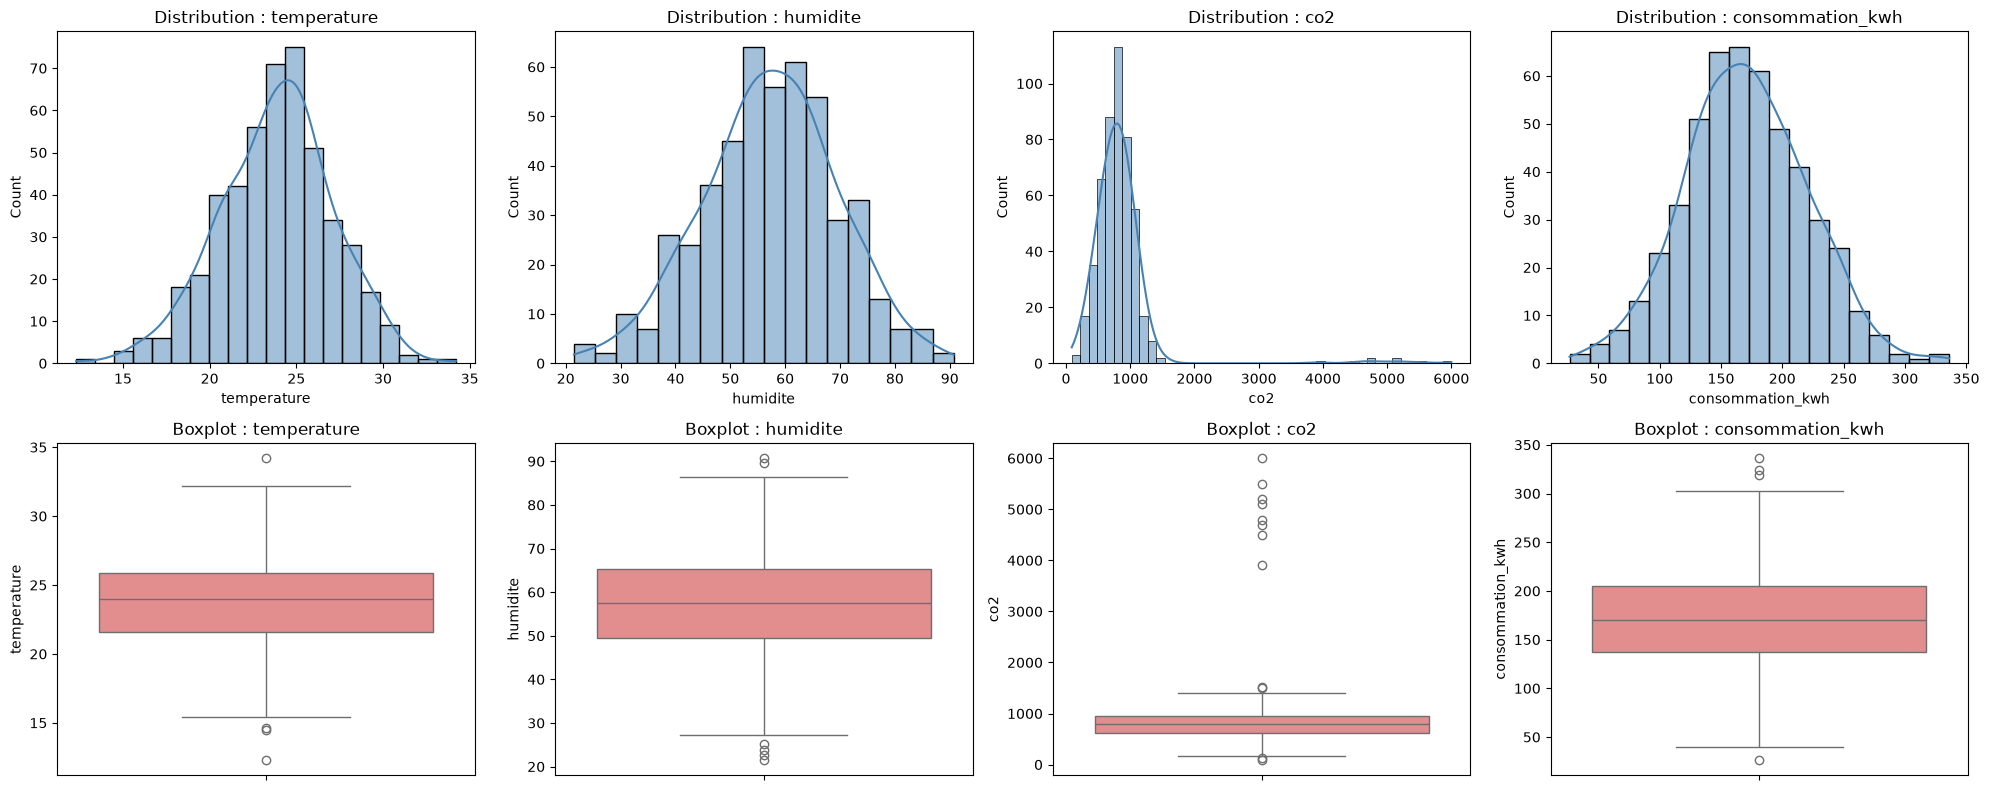

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

vars_visu = ['temperature', 'humidite', 'co2', 'consommation_kwh']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, col in enumerate(vars_visu):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'Distribution : {col}')
    sns.boxplot(y=df[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'Boxplot : {col}')
plt.tight_layout()
plt.show()

a) Les distributions (symétrique ou non) 

Température : distribution symétrique, en cloche, centrée autour de 24 °C.
Humidité : distribution à peu près symétrique, en cloche large, centrée autour de 57-58 %.
Consommation : distribution à peu près symétrique, centrée autour de 165-170 kWh.
CO₂ : distribution fortement asymétrique à droite. La majorité des valeurs se concentre autour de 800 ppm, et un petit groupe de valeurs très élevées (environ 3 900 à 6 000 ppm) étire la queue à droite.

b) La dispersion 

Humidité (environ 21 à 91 %) et consommation (environ 25 à 335 kWh) sont les plus dispersées, avec des boîtes larges.
Température est resserrée (boîte d'environ 21,5 à 26 °C).
CO₂ a une boîte très étroite (environ 600 à 950 ppm) : les valeurs typiques sont regroupées. Mais l'étendue totale est énorme (environ 100 à 6 000 ppm) à cause des valeurs extrêmes.

c) Valeurs extrêmes

Température : quelques points isolés vers 12-14 °C et un vers 34 °C.
Humidité : quelques points vers 21-25 % et 89-91 %.
CO₂ : un groupe d'environ huit points entre 3 900 et 6 000 ppm, deux points vers 1 500 ppm et deux points vers 100 ppm.
Consommation : un point vers 25 kWh et trois points entre 320 et 335 kWh.

d) les valeurs potentiellement aberrantes

Température, humidité, consommation : les points hors moustaches sont modérés et restent physiquement plausibles. Ce sont des valeurs extrêmes probablement réelles, pas des erreurs.
CO₂ entre 3 900 et 6 000 ppm : nettement séparées du reste (le trou après 1 500 ppm). Ce sont les valeurs les plus suspectes du jeu de données : erreur de capteur, ou situation réelle de très mauvaise ventilation.
CO₂ vers 100 ppm : suspect, car inférieur au niveau de l'air extérieur (environ 420 ppm).
Les valeurs erronées évidentes (températures de -30 et -25 °C) ont été transformées en NaN à la question 12f.

16) Quelle stratégie utiliser pour les valeurs aberrantes ? 

On distingue d'abord l'erreur de la valeur extrême réelle. Les valeurs impossibles (humidité négative, températures de -30 °C, consommation négative) sont transformées en NaN, puis imputées par la médiane dans le pipeline. Les valeurs extrêmes plausibles (pics de consommation, températures et humidités aux extrémités) sont conservées : elles reflètent des situations réelles, et l'objectif du projet est justement de détecter les situations anormales, donc les supprimer détruirait le signal. Pour le CO₂, les valeurs entre 3 900 et 6 000 ppm sont examinées en fonction de l'occupation et de l'alerte : conservées si elles correspondent à de vraies situations, mises à NaN sinon.